## Comparison of ESA CCI Snow LAC and GAC data
#### Using values processed with lac_gac.py
#### Author: Elias Frey, RSGB/Unibe, 25.06.2024

### Import statements

In [1]:
import os
import warnings
import csv
import glob
from datetime import datetime
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from collections import defaultdict

### Functions

In [2]:
def get_coords():
    """
    Get region name and coordinate
    """
    coords_dict = {
            'Alaska_USA': [66.16, -153.37],                # Gates of the Arctic National Park, forest
            'Auyuittuq_Canada': [67.5, -65],       # Auyuittuq National Park, mountains
            'San_Rafael_South_America': [-46.76, 73,55],           # Parque Nacional Laguna San Rafael, glacier
            'Berlevåg_Norway': [70.85, 29.08],      # urban, desert
            'Salekhard_Russia': [66.32, 66.37],           # urban, forest
            'Siberia_Russia': [63.32, 115.21],         # forest
        }
    return coords_dict

In [3]:
def get_csv_path(csv_main_dir, region):
    """
    Get csv file from directory
    """
    csv_file = glob.glob(os.path.join(path_to_csv_files, f"{region}*.csv"))[0]
    return csv_file

In [4]:
def get_csv_file(filename):
    """
    Get path of csv file for single plotting
    """
    parts = filename.split("_")
    csv_path = f'csv/{parts[3]}_{parts[4]}/{filename}.csv'
    return csv_path

In [5]:
def read_csv(csv_path):
    """
    Read csv file
    """
    # Initialize empty dictionary to store data
    csv_dict = defaultdict(lambda: defaultdict(lambda: defaultdict(lambda: defaultdict(list))))
    
    # Read data from CSV file and populate dictionary
    with open(csv_path, 'r', newline='') as csv_file:
        reader = csv.DictReader(csv_file)
        for row in reader:
            date_str = row['date']
            platform = row['datatype']
            satellite = row['satellite']
            region = row['region']
            data_str = row['data']
            
            # Convert date string to datetime object
            date = datetime.strptime(date_str, '%Y%m%d').strftime('%d-%m-%Y')
            
            # Convert data string to list of floats, handling NaN values
            data = [np.nan if val == 'nan' else float(val) for val in data_str.strip('[]').split(',')]
            
            # Update dictionary
            csv_dict[date][platform][satellite][region] = data

    return csv_dict

In [6]:
def filter_dates(data, start_date, end_date, date_format="%d-%m-%Y"):
    """
    Filters the data dictionary to include only entries within the specified date range
    """
    start = datetime.strptime(start_date, date_format)
    end = datetime.strptime(end_date, date_format)

    filtered_data = defaultdict(lambda: defaultdict(lambda: defaultdict(lambda: defaultdict(list))))

    for date_str, value in data.items():
        date = datetime.strptime(date_str, date_format)
        if start <= date <= end:
            filtered_data[date_str] = value

    return filtered_data

In [7]:
def get_regionstring(csv_path):
    country, region = os.path.basename(csv_path).split('_')[0:2]
    plot_title = f"{region.capitalize()} ({country.upper()})"
    return plot_title

In [8]:
def plot_comparison(var_dict, csv_path, plot_category, date_range):
    """
    Plot comparison of LAC and GAC with specified parameters
    """
    # Ignore NaN values warning
    warnings.filterwarnings("ignore", category=RuntimeWarning, message="All-NaN axis encountered")

    # Create empty arrays
    x = list(var_dict.keys())
    lac_noaa11_y = [np.nan] * len(x)
    gac_noaa11_y = [np.nan] * len(x)
    lac_noaa14_y = [np.nan] * len(x)
    gac_noaa14_y = [np.nan] * len(x)
    
    for i, (date, data) in enumerate(var_dict.items()):
        for platform, platform_data in data.items():
            for satellite, satellite_data in platform_data.items():
                for region, region_data in satellite_data.items():  # Iterate over regions
                    if region_data:  # Check if region data is not empty
                        max_value = np.nanmax(region_data)
                        if not np.isnan(max_value):
                            category = int(max_value / 10) * 10  # Convert max_value to category
                            if platform == 'lac' and satellite == 'noaa11':
                                if plot_category:
                                    lac_noaa11_y[i] = category
                                else:
                                    lac_noaa11_y[i] = max_value
                            elif platform == 'gac' and satellite == 'noaa11':
                                if plot_category:
                                    gac_noaa11_y[i] = category
                                else:
                                    gac_noaa11_y[i] = max_value
                            elif platform == 'lac' and satellite == 'noaa14':
                                if plot_category:
                                    lac_noaa14_y[i] = category
                                else:
                                    lac_noaa14_y[i] = max_value
                            elif platform == 'gac' and satellite == 'noaa14':
                                if plot_category:
                                    gac_noaa14_y[i] = category
                                else:
                                    gac_noaa14_y[i] = max_value
    
    

    plt.figure(figsize=(10, 6))    
    
    # Plot lines only for satellite category containig data
    if not all(i != i for i in lac_noaa11_y):
        plt.plot(x, lac_noaa11_y, label='LAC NOAA11', marker='o', linestyle='', color='#38b000')
    if not all(i != i for i in lac_noaa14_y):
        plt.plot(x, lac_noaa14_y, label='LAC NOAA14', marker='o', linestyle='', color='#31572c')
    if not all(i != i for i in gac_noaa11_y):
        plt.plot(x, gac_noaa11_y, label='GAC NOAA11', marker='o', linestyle='', color='#ffdd00')
    if not all(i != i for i in gac_noaa14_y):
        plt.plot(x, gac_noaa14_y, label='GAC NOAA14', marker='o', linestyle='', color='#ffb703')
    
    # Set plot labels and title
    plt.xlabel('')
    plt.ylabel('Snow Cover Fraction [%]')
    csv_name = get_regionstring(csv_path)
    if plot_category:
        plt.title(f'Comparison of LAC & GAC SCFV (10-stage) {csv_name}')
    else:
        plt.title(f'Comparison of LAC & GAC SCFV {csv_name}')
    
    # Add legend
    plt.legend()
    plt.xticks(np.arange(0, len(x), step=max(len(x)//10, 1)), rotation=45)
    plt.tight_layout()  
    plt.grid(False)  
    plt.savefig(f'plots/{date_range}/{csv_name}_SCFV_comparison_{date_range}.png')
    plt.show()

In [9]:
def plot_difference(var_dict, csv_path, date_range):
    """
    Plot differences of LAC and GAC with specified parameters
    """
    # Ignore NaN values warning
    warnings.filterwarnings("ignore", category=RuntimeWarning, message="All-NaN axis encountered")

    # Create empty arrays
    x = list(var_dict.keys())
    lac_noaa11_y = [np.nan] * len(x)
    gac_noaa11_y = [np.nan] * len(x)
    lac_noaa14_y = [np.nan] * len(x)
    gac_noaa14_y = [np.nan] * len(x)
    
    for i, (date, data) in enumerate(var_dict.items()):
        for platform, platform_data in data.items():
            for satellite, satellite_data in platform_data.items():
                for region, region_data in satellite_data.items():  # Iterate over regions
                    if region_data:  # Check if region data is not empty
                        max_value = np.nanmax(region_data)
                        if not np.isnan(max_value):
                            category = int(max_value / 10) * 10  # Convert max_value to category
                            if platform == 'lac' and satellite == 'noaa11':
                                lac_noaa11_y[i] = category
                            elif platform == 'gac' and satellite == 'noaa11':
                                gac_noaa11_y[i] = category
                            elif platform == 'lac' and satellite == 'noaa14':
                                lac_noaa14_y[i] = category
                            elif platform == 'gac' and satellite == 'noaa14':
                                gac_noaa14_y[i] = category
    
    
    # Create arrays from lists
    arr1 = np.array(lac_noaa11_y)
    arr2 = np.array(gac_noaa11_y)
    arr3= np.array(lac_noaa14_y)
    arr4 = np.array(gac_noaa14_y)
    
    # Calculate differences, ignoring NaN values
    differences1 = np.where(np.isnan(arr1) | np.isnan(arr2), np.nan, arr1 - arr2)
    differences2 = np.where(np.isnan(arr3) | np.isnan(arr4), np.nan, arr3 - arr4)
    
    # Plot data
    plt.figure(figsize=(10, 6))
    
    plt.plot(x, differences1, label='LAC-GAC NOAA11', marker='.', linestyle='', color='#0077b6')
    plt.plot(x, differences2, label='LAC-GAC NOAA14', marker='.', linestyle='', color='#023e8a')
    
    # Set plot labels and title
    plt.xlabel('')
    plt.ylabel('Differences in Snow Cover Fraction [%]')
    csv_name = get_regionstring(csv_path)
    plt.title(f'Differences of LAC - GAC SCFV (10-step) {csv_name}')
    
    # Add legend
    plt.legend()
    plt.xticks(np.arange(0, len(x), step=max(len(x)//10, 1)), rotation=45)
    plt.tight_layout()
    plt.grid(False)
    
    plt.savefig(f'plots/{date_range}/{csv_name}_SCFV_difference_{date_range}.png')
    plt.show()

### User input

In [10]:
### DEFINE PLOT PARAMETERS ###

# Csv file name
path_to_csv_files = 'csv/'

# Range of Plot date
start_date = '04-01-1992'
end_date = '04-02-1992'

# Comparision plots
plot_category = False               # Categorize SCF values (10-stages)
fullrange_comparison = False        # Ignores start_date and end_date for comparison plots

# Differences plots
fullrange_differences = True        # Ignores start_date and end_date for difference plots

### Plotting

In [11]:
date_range = start_date.replace('-', '') + '_' + end_date.replace('-', '') # Create string for folder name
# Create dirs
if not os.path.isdir('plots/'):
    os.makedirs('plots/')
if not os.path.isdir(f'plots/{date_range}/'):
    os.makedirs(f'plots/{date_range}/')

for region, coords in get_coords().items():
    csv_path = get_csv_path(path_to_csv_files, region)
    csv_file = read_csv(csv_path)
    filtered_data = filter_dates(csv_file, start_date, end_date)
    # Plot
    if fullrange_comparison:
        plot_comparison(var_dict = csv_file, csv_path = csv_path, plot_category = plot_category, date_range=date_range)
    else:
        plot_comparison(var_dict = filtered_data, csv_path = csv_path, plot_category = plot_category, date_range=date_range)
    
    if fullrange_differences:
        plot_difference(var_dict = csv_file, csv_path = csv_path, date_range = date_range)
    else:
        plot_difference(var_dict = filtered_data, csv_path = csv_path, date_range = date_range)

IndexError: list index out of range

In [ ]:
import glob

date_range = start_date.replace('-', '') + '_' + end_date.replace('-', '')  # Create string for folder name

# Create dirs
if not os.path.isdir('plots/'):
    os.makedirs('plots/')
if not os.path.isdir(f'plots/{date_range}/'):
    os.makedirs(f'plots/{date_range}/')

# quick sanity check before the loop
print("Looking in:", path_to_csv_files)
print("Exists:", os.path.isdir(path_to_csv_files))
if os.path.isdir(path_to_csv_files):
    print("Contents:", os.listdir(path_to_csv_files))

for region, coords in get_coords().items():
    matches = glob.glob(os.path.join(path_to_csv_files, f"{region}*.csv"))
    if not matches:
        print(f"⚠️  No CSV found for region '{region}' in '{path_to_csv_files}' — skipping.")
        continue
    csv_path = matches[0]

    csv_file = read_csv(csv_path)
    filtered_data = filter_dates(csv_file, start_date, end_date)

    # Plot
    if fullrange_comparison:
        plot_comparison(var_dict=csv_file, csv_path=csv_path, plot_category=plot_category, date_range=date_range)
    else:
        plot_comparison(var_dict=filtered_data, csv_path=csv_path, plot_category=plot_category, date_range=date_range)

    if fullrange_differences:
        plot_difference(var_dict=csv_file, csv_path=csv_path, date_range=date_range)
    else:
        plot_difference(var_dict=filtered_data, csv_path=csv_path, date_range=date_range)

### Create single plots

In [46]:
### DEFINE PLOT PARAMETERS ###

# Csv file name
csv_filename = 'ger_blackforest_values_20240618_135418'

# Range of Plot date
start_date = '01-10-1992'
end_date = '01-06-1993'

# Comparision plots
plot_category = False               # Categorize SCF values (10-stages)
fullrange_comparison = False        # ignores start_date and end_date for comparison plots

# Differences plots
fullrange_differences = True        # ignores start_date and end_date for difference plots

In [24]:
# Define the CSV file path
csv_path = get_csv_file(csv_filename)

In [25]:
# Read csv file
new_dict = read_csv(csv_path)

In [28]:
# Filter data by defined time span
filtered_data = filter_dates(new_dict, start_date, end_date)

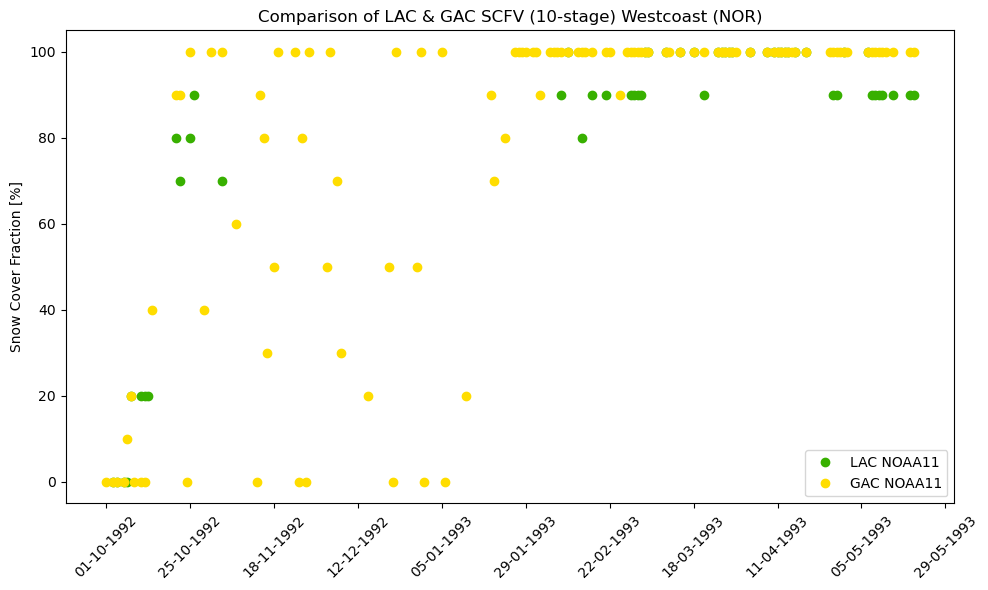

In [40]:
# Plot
if fullrange_comparison:
    plot_comparison(var_dict = new_dict, csv_path = csv_path, plot_category = plot_category, date_range=date_range)
else:
    plot_comparison(var_dict = filtered_data, csv_path = csv_path, plot_category = plot_category, date_range=date_range)

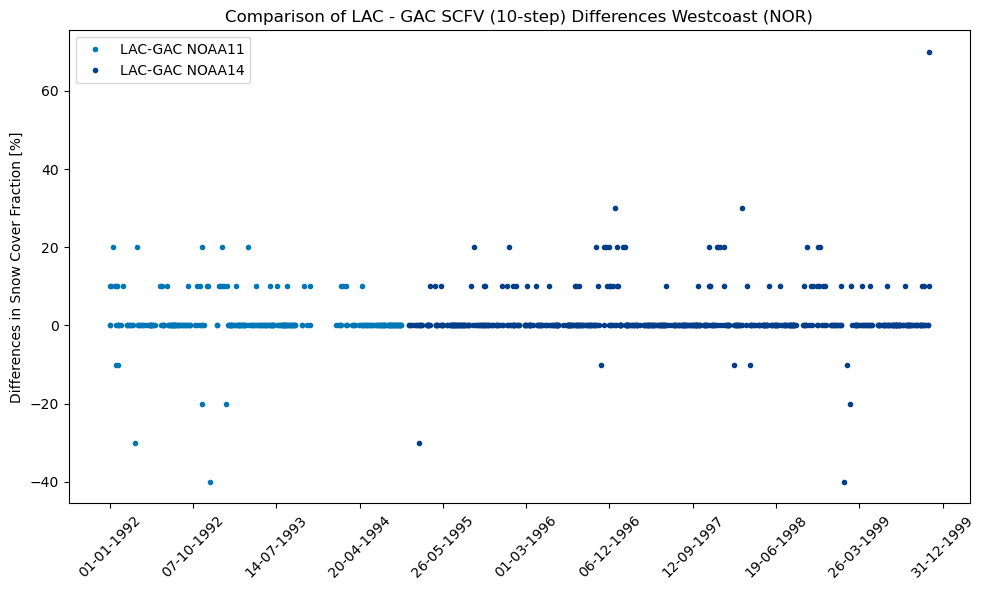

In [41]:
# Plot
if fullrange_differences:
    plot_difference(var_dict = new_dict, csv_path = csv_path, date_range=date_range)
else:
    plot_difference(var_dict = filtered_data, csv_path = csv_path, date_range=date_range)